In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# -----------------------------
# Setup
# -----------------------------
sys.path.insert(0, str(Path.cwd() / "rebuild"))

OUTPUT_DIR = Path("./rebuild_outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_results = pd.read_csv(TABLES_DIR / "results_all.csv")

print("✓ Loaded results from rebuild_outputs/")
print(f"  Total rows: {len(df_results)}")
print(f"  Models: {df_results['model'].unique().tolist()}")
print(f"  Mitigations: {df_results['mitigation'].unique().tolist()}")
print(f"  Perturbations: {df_results['perturbation'].unique().tolist()}")

# -----------------------------
# Labels and ordering
# -----------------------------
perturbation_map = {
    "D0": "Original",
    "D1A": "Row Removal",
    "D2A": "MAR"
}

mitigation_map = {
    "none": "None",
    "reweighting": "Reweighting",
    "smote": "SMOTE",
    "fairness_penalty": "Fairness Penalty"
}

perturbation_order = ["Original", "Row Removal", "MAR"]
mitigation_order = ["None", "Reweighting", "SMOTE", "Fairness Penalty"]
mitigation_short = ["None", "Reweight", "SMOTE", "Fairness<br>Penalty"]

models = ["LogisticGLM", "GRU", "XGBoost"]

metrics = {
    "Utility": {
        "col": "overall_physionet_utility",
        "ideal": 1.0,
        "distance_fn": lambda x: np.abs(1 - x),
        "axis_title": "Utility",
    },
    "Disparate Impact": {
        "col": "disparate_impact",
        "ideal": 1.0,
        "distance_fn": lambda x: np.abs(x - 1),
        "axis_title": "Disparate Impact",
    },
    "Equal Opportunity": {
        "col": "equal_opportunity",
        "ideal": 0.0,
        "distance_fn": lambda x: np.abs(x),
        "axis_title": "Equal Opportunity",
    }
}

plot_df = df_results.copy()
plot_df["perturbation"] = plot_df["perturbation"].replace(perturbation_map)
plot_df["mitigation"] = plot_df["mitigation"].replace(mitigation_map)

plot_df["perturbation"] = pd.Categorical(
    plot_df["perturbation"],
    categories=perturbation_order,
    ordered=True
)

plot_df["mitigation"] = pd.Categorical(
    plot_df["mitigation"],
    categories=mitigation_order,
    ordered=True
)

# -----------------------------
# Summary with percentile CIs
# -----------------------------
summary_parts = []

for metric_name, info in metrics.items():
    metric_col = info["col"]

    tmp = (
        plot_df
        .groupby(["model", "perturbation", "mitigation"], observed=False)
        .agg(
            mean=(metric_col, "mean"),
            lower=(metric_col, lambda x: np.nanpercentile(x, 2.5)),
            upper=(metric_col, lambda x: np.nanpercentile(x, 97.5)),
            n=(metric_col, lambda x: x.notna().sum())
        )
        .reset_index()
    )

    tmp["metric"] = metric_name
    tmp["ideal"] = info["ideal"]
    tmp["distance"] = info["distance_fn"](tmp["mean"])

    summary_parts.append(tmp)

df_metric_summary = pd.concat(summary_parts, ignore_index=True)

# Save summary table for report use
summary_out = TABLES_DIR / "metric_summary_with_ci.csv"
df_metric_summary.to_csv(summary_out, index=False)
print(f"✓ Saved summary table: {summary_out}")

✓ Loaded results from rebuild_outputs/
  Total rows: 36000
  Models: ['LogisticGLM', 'XGBoost', 'GRU']
  Mitigations: ['none', 'reweighting', 'smote', 'fairness_penalty']
  Perturbations: ['D0', 'D1A', 'D2A']
✓ Saved summary table: rebuild_outputs/tables/metric_summary_with_ci.csv


In [4]:
# -----------------------------
# Figure 1: Distance from Ideal Heatmap
# -----------------------------
fig = make_subplots(
    rows=3,
    cols=3,
    subplot_titles=models,
    horizontal_spacing=0.055,
    vertical_spacing=0.105
)

# Choose a robust shared upper limit so extreme DI values do not dominate everything
distance_cap = np.nanpercentile(df_metric_summary["distance"], 95)
distance_cap = max(distance_cap, 0.05)

for row_i, metric_name in enumerate(metrics.keys(), start=1):
    df_metric = df_metric_summary[df_metric_summary["metric"] == metric_name]

    for col_i, model_name in enumerate(models, start=1):
        df_model = df_metric[df_metric["model"] == model_name]

        pivot_distance = df_model.pivot_table(
            index="perturbation",
            columns="mitigation",
            values="distance",
            aggfunc="first",
            observed=False
        ).reindex(index=perturbation_order, columns=mitigation_order)

        pivot_mean = df_model.pivot_table(
            index="perturbation",
            columns="mitigation",
            values="mean",
            aggfunc="first",
            observed=False
        ).reindex(index=perturbation_order, columns=mitigation_order)

        pivot_lower = df_model.pivot_table(
            index="perturbation",
            columns="mitigation",
            values="lower",
            aggfunc="first",
            observed=False
        ).reindex(index=perturbation_order, columns=mitigation_order)

        pivot_upper = df_model.pivot_table(
            index="perturbation",
            columns="mitigation",
            values="upper",
            aggfunc="first",
            observed=False
        ).reindex(index=perturbation_order, columns=mitigation_order)

        text = pivot_mean.copy().astype(object)

        for r in pivot_mean.index:
            for c in pivot_mean.columns:
                mean = pivot_mean.loc[r, c]
                lower = pivot_lower.loc[r, c]
                upper = pivot_upper.loc[r, c]

                if pd.isna(mean):
                    text.loc[r, c] = ""
                else:
                    text.loc[r, c] = f"{mean:.3f}<br>[{lower:.3f}, {upper:.3f}]"

        fig.add_trace(
            go.Heatmap(
                z=np.clip(pivot_distance.values, 0, distance_cap),
                x=mitigation_order,
                y=perturbation_order,
                coloraxis="coloraxis",
                text=text.values,
                texttemplate="%{text}",
                textfont=dict(size=8),
                hovertemplate=(
                    "Dataset: %{y}<br>"
                    "Mitigation: %{x}<br>"
                    f"{metric_name}: %{{text}}<br>"
                    "Distance from ideal: %{z:.3f}<extra></extra>"
                )
            ),
            row=row_i,
            col=col_i
        )

fig.update_layout(
    coloraxis=dict(
        colorscale="Reds",
        cmin=0,
        cmax=distance_cap,
        colorbar=dict(
            title="Distance<br>from ideal"
        )
    ),
    height=1000,
    width=1350,
    margin=dict(l=130, r=100, t=90, b=95),
    title=dict(
        text="Model Performance and Fairness Relative to Metric-Specific Ideals",
        x=0.5,
        xanchor="center"
    )
)

# Row labels with ideals
row_labels = [
    "Utility<br>(ideal = 1)",
    "Disparate Impact<br>(ideal = 1)",
    "Equal Opportunity<br>(ideal = 0)"
]

row_y = [0.855, 0.500, 0.145]

for label, y in zip(row_labels, row_y):
    fig.add_annotation(
        text=f"<b>{label}</b>",
        xref="paper",
        yref="paper",
        x=-0.085,
        y=y,
        showarrow=False,
        textangle=-90,
        font=dict(size=15)
    )

# Hide repeated x labels except bottom row
for row in [1, 2]:
    for col in [1, 2, 3]:
        fig.update_xaxes(showticklabels=False, row=row, col=col)

# Show shortened x labels on bottom row only
for col in [1, 2, 3]:
    fig.update_xaxes(
        tickmode="array",
        tickvals=mitigation_order,
        ticktext=mitigation_short,
        tickangle=0,
        row=3,
        col=col
    )

# Hide repeated y labels except first column
for row in [1, 2, 3]:
    for col in [2, 3]:
        fig.update_yaxes(showticklabels=False, row=row, col=col)

fname = "figure_1_distance_from_ideal_heatmap_CI.png"

try:
    fig.write_image(str(FIGURES_DIR / fname), scale=2, width=1350, height=1000)
    print(f"✓ Saved: {FIGURES_DIR / fname}")
except Exception as e:
    print(f"⚠ Could not save {fname}: {e}")

fig.show()

✓ Saved: rebuild_outputs/figures/figure_1_distance_from_ideal_heatmap_CI.png


✓ Saved: rebuild_outputs/figures/figure_2_raw_metrics_CI_filled_markers.png


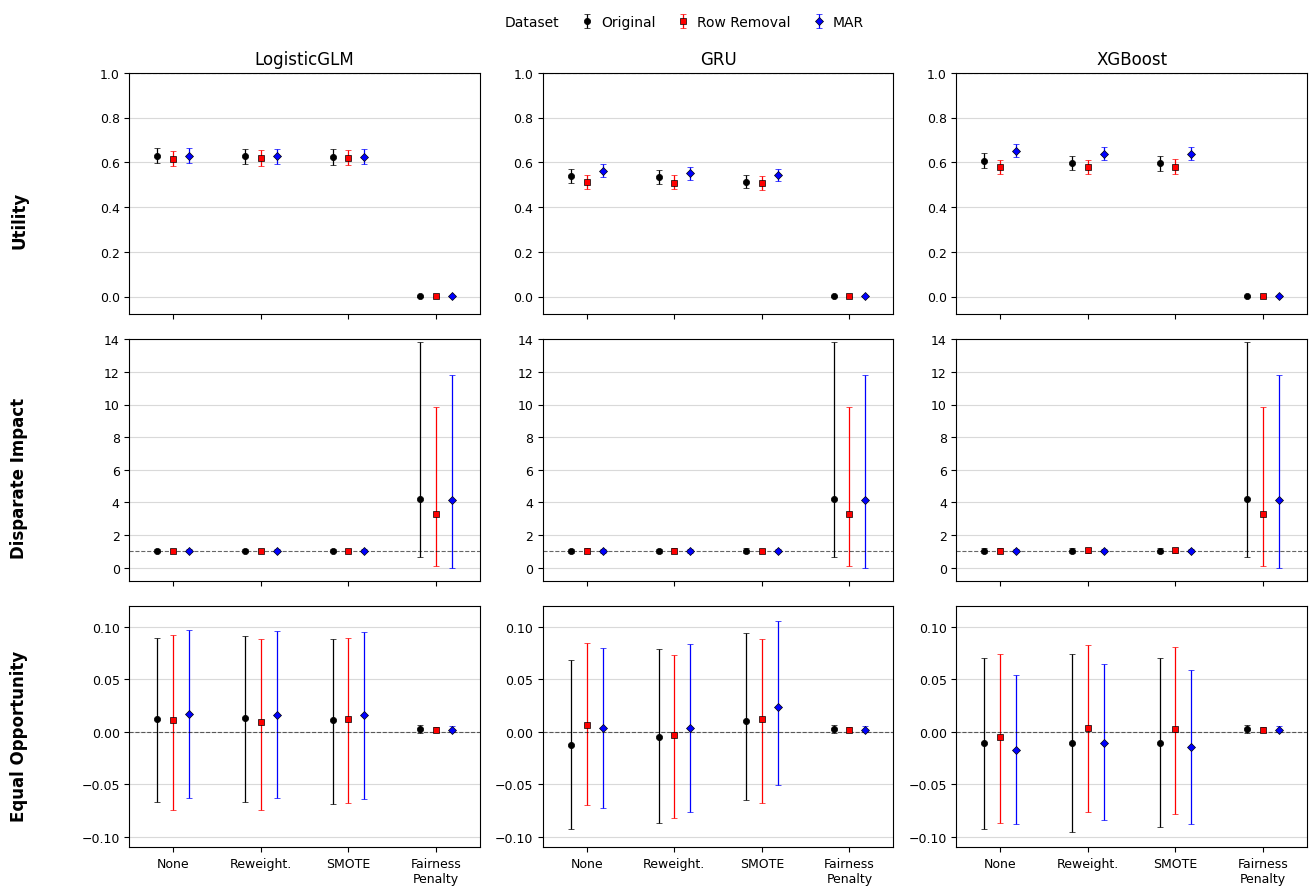

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Figure 2: Raw Metric Values with 95% CIs
# Classic matplotlib style with small filled markers
# -----------------------------

colors = {
    "Original": "black",
    "Row Removal": "red",
    "MAR": "blue"
}

markers = {
    "Original": "o",
    "Row Removal": "s",
    "MAR": "D"
}

offsets = {
    "Original": -0.18,
    "Row Removal": 0.0,
    "MAR": 0.18
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(13.5, 9.5),
    sharex=True
)

for row_i, metric_name in enumerate(metrics.keys()):
    df_metric = df_metric_summary[df_metric_summary["metric"] == metric_name]
    ideal = metrics[metric_name]["ideal"]

    for col_i, model_name in enumerate(models):
        ax = axes[row_i, col_i]
        df_panel = df_metric[df_metric["model"] == model_name].copy()

        for dataset in perturbation_order:
            d = df_panel[df_panel["perturbation"] == dataset].copy()

            x = np.array([mitigation_order.index(m) for m in d["mitigation"]])
            x = x + offsets[dataset]

            y = d["mean"].values
            yerr = np.vstack([
                y - d["lower"].values,
                d["upper"].values - y
            ])

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                fmt=markers[dataset],
                color=colors[dataset],
                markerfacecolor=colors[dataset],
                markeredgecolor="black",
                markeredgewidth=0.5,
                markersize=4.5,
                capsize=2,
                elinewidth=0.9,
                linewidth=0.9,
                label=dataset if (row_i == 0 and col_i == 0) else None
            )

        ax.axhline(
            ideal,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.6
        )

        ax.grid(axis="y", color="0.85", linewidth=0.8)
        ax.set_axisbelow(True)

        for spine in ax.spines.values():
            spine.set_color("black")
            spine.set_linewidth(0.8)

        if row_i == 0:
            ax.set_title(model_name, fontsize=12)

        ax.set_xlim(-0.5, len(mitigation_order) - 0.5)
        ax.tick_params(axis="both", labelsize=9)

# consistent y ranges
for col_i in range(3):
    axes[0, col_i].set_ylim(-0.08, 1.0)
    axes[1, col_i].set_ylim(-0.8, 14.0)
    axes[2, col_i].set_ylim(-0.11, 0.12)

# bottom x labels only
for ax in axes[-1, :]:
    ax.set_xticks(range(len(mitigation_order)))
    ax.set_xticklabels(
        ["None", "Reweight.", "SMOTE", "Fairness\nPenalty"],
        fontsize=9
    )

# aligned vertical row labels (exactly centered to each row)
row_labels = ["Utility", "Disparate Impact", "Equal Opportunity"]

for i, label in enumerate(row_labels):
    ax = axes[i, 0]  # leftmost subplot in each row
    bbox = ax.get_position()  # figure-relative coordinates

    y_center = (bbox.y0 + bbox.y1) / 2  # vertical center of that row

    fig.text(
        0.015,                 # fixed x position
        y_center,              # true center
        label,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

# inline horizontal legend
handles, labels = axes[0, 0].get_legend_handles_labels()
dummy = plt.Line2D([], [], linestyle="none", marker=None)

handles = [dummy] + handles
labels = ["Dataset"] + labels

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    fontsize=10,
    columnspacing=1.5,
    handletextpad=0.5,
    handlelength=1.0
)

# no main title
fig.tight_layout(rect=[0.05, 0.05, 0.98, 0.96])

fname = FIGURES_DIR / "figure_2_raw_metrics_CI_filled_markers.png"
fig.savefig(fname, dpi=300, bbox_inches="tight")
fig.savefig(fname.with_suffix(".pdf"), bbox_inches="tight")

print(f"✓ Saved: {fname}")
plt.show()

In [20]:
# -----------------------------
# Appendix table: raw metric values with 95% CIs
# -----------------------------

table_df = df_metric_summary.copy()

table_df["Estimate [95% CI]"] = table_df.apply(
    lambda r: f"{r['mean']:.3f} [{r['lower']:.3f}, {r['upper']:.3f}]"
    if pd.notna(r["mean"]) else "",
    axis=1
)

table_df["metric"] = pd.Categorical(
    table_df["metric"],
    categories=["Utility", "Disparate Impact", "Equal Opportunity"],
    ordered=True
)

table_df["model"] = pd.Categorical(
    table_df["model"],
    categories=models,
    ordered=True
)

table_df["perturbation"] = pd.Categorical(
    table_df["perturbation"],
    categories=perturbation_order,
    ordered=True
)

table_df["mitigation"] = pd.Categorical(
    table_df["mitigation"],
    categories=mitigation_order,
    ordered=True
)

table_df = table_df.sort_values(
    ["metric", "model", "perturbation", "mitigation"]
)

# Wide format: mitigation methods as columns
wide = table_df.pivot_table(
    index=["metric", "model", "perturbation"],
    columns="mitigation",
    values="Estimate [95% CI]",
    aggfunc="first",
    observed=False
).reset_index()

wide = wide.rename(columns={
    "metric": "Metric",
    "model": "Model",
    "perturbation": "Dataset"
})

wide = wide[[
    "Metric",
    "Model",
    "Dataset",
    "None",
    "Reweighting",
    "SMOTE",
    "Fairness Penalty"
]]

# Save CSV
csv_path = TABLES_DIR / "appendix_raw_metric_values_ci.csv"
wide.to_csv(csv_path, index=False)

# Save LaTeX
latex = wide.to_latex(
    index=False,
    escape=False,
    longtable=True,
    caption="Raw metric estimates with 95\\% bootstrap confidence intervals. Values correspond to Figure 2.",
    label="tab:raw_metric_values_ci",
    column_format="lllrrrr"
)

tex_path = TABLES_DIR / "appendix_raw_metric_values_ci.tex"
with open(tex_path, "w") as f:
    f.write(latex)

print(f"✓ Saved CSV: {csv_path}")
print(f"✓ Saved LaTeX: {tex_path}")

wide

✓ Saved CSV: rebuild_outputs/tables/appendix_raw_metric_values_ci.csv
✓ Saved LaTeX: rebuild_outputs/tables/appendix_raw_metric_values_ci.tex


mitigation,Metric,Model,Dataset,None,Reweighting,SMOTE,Fairness Penalty
0,Utility,LogisticGLM,Original,"0.630 [0.597, 0.663]","0.627 [0.593, 0.661]","0.624 [0.590, 0.659]","0.002 [-0.000, 0.003]"
1,Utility,LogisticGLM,Row Removal,"0.616 [0.581, 0.650]","0.618 [0.583, 0.653]","0.620 [0.586, 0.654]","0.001 [-0.000, 0.002]"
2,Utility,LogisticGLM,MAR,"0.630 [0.597, 0.663]","0.627 [0.593, 0.661]","0.624 [0.591, 0.659]","0.001 [-0.000, 0.003]"
3,Utility,GRU,Original,"0.539 [0.509, 0.571]","0.533 [0.503, 0.567]","0.512 [0.483, 0.543]","0.002 [-0.000, 0.003]"
4,Utility,GRU,Row Removal,"0.511 [0.480, 0.543]","0.509 [0.479, 0.541]","0.508 [0.477, 0.538]","0.001 [-0.000, 0.002]"
5,Utility,GRU,MAR,"0.561 [0.533, 0.590]","0.551 [0.523, 0.580]","0.542 [0.515, 0.572]","0.001 [-0.000, 0.003]"
6,Utility,XGBoost,Original,"0.605 [0.574, 0.640]","0.596 [0.564, 0.630]","0.595 [0.563, 0.628]","0.002 [-0.000, 0.003]"
7,Utility,XGBoost,Row Removal,"0.577 [0.546, 0.611]","0.578 [0.546, 0.612]","0.580 [0.549, 0.615]","0.001 [-0.000, 0.002]"
8,Utility,XGBoost,MAR,"0.651 [0.623, 0.682]","0.638 [0.610, 0.670]","0.638 [0.609, 0.670]","0.001 [-0.000, 0.003]"
9,Disparate Impact,LogisticGLM,Original,"1.036 [0.953, 1.130]","1.036 [0.953, 1.130]","1.037 [0.953, 1.131]","4.227 [0.663, 13.803]"


In [21]:
# -----------------------------
# Appendix table: LaTeX-ready formatted output
# -----------------------------

table_df = df_metric_summary.copy()

# Format estimate + CI
table_df["Estimate"] = table_df.apply(
    lambda r: f"{r['mean']:.3f} [{r['lower']:.3f}, {r['upper']:.3f}]"
    if pd.notna(r["mean"]) else "",
    axis=1
)

# Ordering
table_df["metric"] = pd.Categorical(
    table_df["metric"],
    categories=["Utility", "Disparate Impact", "Equal Opportunity"],
    ordered=True
)

table_df["model"] = pd.Categorical(
    table_df["model"],
    categories=models,
    ordered=True
)

table_df["perturbation"] = pd.Categorical(
    table_df["perturbation"],
    categories=perturbation_order,
    ordered=True
)

table_df["mitigation"] = pd.Categorical(
    table_df["mitigation"],
    categories=mitigation_order,
    ordered=True
)

table_df = table_df.sort_values(
    ["metric", "model", "perturbation", "mitigation"]
)

# Pivot to wide format
wide = table_df.pivot_table(
    index=["metric", "model", "perturbation"],
    columns="mitigation",
    values="Estimate",
    aggfunc="first",
    observed=False
).reset_index()

wide.columns.name = None

wide = wide.rename(columns={
    "metric": "Metric",
    "model": "Model",
    "perturbation": "Dataset",
    "None": "None",
    "Reweighting": "Reweight.",
    "SMOTE": "SMOTE",
    "Fairness Penalty": "Fairness Penalty"
})

# -----------------------------
# Build LaTeX manually (for multirow control)
# -----------------------------

latex_lines = []

latex_lines.append(r"\begin{longtable}{lllcccc}")
latex_lines.append(r"\caption{Raw metric estimates with 95\% bootstrap confidence intervals corresponding to Figure~2.}\\")
latex_lines.append(r"\toprule")
latex_lines.append(r"Metric & Model & Dataset & None & Reweight. & SMOTE & Fairness Penalty \\")
latex_lines.append(r"\midrule")
latex_lines.append(r"\endfirsthead")
latex_lines.append(r"\toprule")
latex_lines.append(r"Metric & Model & Dataset & None & Reweight. & SMOTE & Fairness Penalty \\")
latex_lines.append(r"\midrule")
latex_lines.append(r"\endhead")

# Build grouped rows
for metric in wide["Metric"].unique():
    df_m = wide[wide["Metric"] == metric]
    metric_rows = len(df_m)

    first_metric = True

    for model in df_m["Model"].unique():
        df_mod = df_m[df_m["Model"] == model]
        model_rows = len(df_mod)

        first_model = True

        for _, row in df_mod.iterrows():
            line = ""

            # Metric multirow
            if first_metric:
                line += rf"\multirow{{{metric_rows}}}{{*}}{{{metric}}} & "
                first_metric = False
            else:
                line += " & "

            # Model multirow
            if first_model:
                line += rf"\multirow{{{model_rows}}}{{*}}{{{model}}} & "
                first_model = False
            else:
                line += " & "

            # Dataset
            line += f"{row['Dataset']} & "

            # Values
            line += " & ".join([
                row["None"],
                row["Reweight."],
                row["SMOTE"],
                row["Fairness Penalty"]
            ])

            line += r" \\"
            latex_lines.append(line)

        latex_lines.append(r"\addlinespace")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{longtable}")

latex_output = "\n".join(latex_lines)

# Save
tex_path = TABLES_DIR / "appendix_raw_metric_values_ci.tex"
with open(tex_path, "w") as f:
    f.write(latex_output)

print(f"✓ Saved LaTeX table: {tex_path}")

✓ Saved LaTeX table: rebuild_outputs/tables/appendix_raw_metric_values_ci.tex


In [7]:
paper_table = df_metric_summary.copy()

paper_table["estimate_ci"] = (
    paper_table["mean"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "") +
    " [" +
    paper_table["lower"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "") +
    ", " +
    paper_table["upper"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "") +
    "]"
)

paper_table = paper_table[
    ["metric", "model", "perturbation", "mitigation", "estimate_ci", "distance", "n"]
].sort_values(["metric", "model", "perturbation", "mitigation"])

paper_table_path = TABLES_DIR / "paper_table_metric_estimates_ci.csv"
paper_table.to_csv(paper_table_path, index=False)

print(f"✓ Saved paper-ready table: {paper_table_path}")

✓ Saved paper-ready table: rebuild_outputs/tables/paper_table_metric_estimates_ci.csv
